# **Praktikum Mandiri 9 — Klasifikasi Penyakit Kanker (Naive Bayes)**
**Dataset:** `data.csv`  

#### **Import Library**

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

#### **Load Dataset**

In [13]:
import os
import shutil # For rmtree
from google.colab import drive

mount_point = '/content/gdrive'

# Check if the mount point exists and is a directory
if os.path.exists(mount_point) and os.path.isdir(mount_point):
    if not os.path.ismount(mount_point): # If it's a directory but not a mount point
        if os.listdir(mount_point): # And it's not empty
            print(f"Warning: Mount point '{mount_point}' exists and contains files but is not mounted. Attempting to clear...")
            try:
                shutil.rmtree(mount_point) # Aggressively remove the directory and its contents
                os.makedirs(mount_point) # Recreate empty directory
                print(f"Cleared and recreated empty mount point '{mount_point}'.")
            except Exception as e:
                print(f"Error clearing mount point '{mount_point}': {e}")
                print("It might be necessary to restart the Colab runtime.")
    else: # It is a mounted drive
        print(f"'{mount_point}' is already a mount point. Attempting to force remount.")
        # force_remount=True will handle unmounting and remounting.
else:
    # If mount_point doesn't exist, drive.mount will create it
    print(f"Mount point '{mount_point}' does not exist, creating it.")
    os.makedirs(mount_point, exist_ok=True)

drive.mount(mount_point, force_remount=True)

# load dataset
cancer_data = pd.read_csv('/content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum09/datasets/data.csv', sep=',')
cancer_data.head()

Cleared and recreated empty mount point '/content/gdrive'.
Mounted at /content/gdrive


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [14]:
# menampilkan 5 baris terakhir data
cancer_data.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [15]:
# jumlah baris dan kolom di data
cancer_data.shape

(569, 33)

#### **Cek Missing Value**

In [16]:
# cek missing value
cancer_data.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [17]:
# identifikasi target & drop kolom tidak relevan

# drop kolom id
if 'id' in cancer_data.columns:
    cancer_data = cancer_data.drop(columns=['id'])
    print("Dropped 'id' column.")

# cek kolom yang mungkin target
possible_targets = [c for c in cancer_data.columns if c.lower() in ('diagnosis','target','class','label','result','outcome','status')]
if possible_targets:
    target_col = possible_targets[0]
else:
    # fallback: gunakan kolom terakhir
    target_col = cancer_data.columns[-1]

print("Target column chosen:", target_col)
print("Unique values in target:", cancer_data[target_col].unique())

Dropped 'id' column.
Target column chosen: diagnosis
Unique values in target: ['M' 'B']


In [18]:
# Hapus kolom yang semua isinya NaN
cancer_data = cancer_data.dropna(axis=1, how='all')
print("Columns after dropping all-NaN columns:", cancer_data.columns)


Columns after dropping all-NaN columns: Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [19]:
# encode target (LabelEncoder)
le_target = LabelEncoder()
cancer_data[target_col] = le_target.fit_transform(cancer_data[target_col].astype(str))
print("Mapping target:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

Mapping target: {'B': np.int64(0), 'M': np.int64(1)}


In [20]:
# cek missing value dan tipe data
print(cancer_data.dtypes)
print("\nMissing values per column:\n", cancer_data.isnull().sum())

diagnosis                    int64
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst            float64
concave points_worst

In [21]:
# pisahkan X dan y
X = cancer_data.drop(columns=[target_col])
y = cancer_data[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [22]:
# tentukan jenis Naive Bayes
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numeric columns: 30
Categorical columns: 0


In [23]:
# Buat pipeline (Imputer -> Scaler -> GaussianNB) ----------
pipeline = Pipeline([
('imputer', SimpleImputer(strategy='median')),
('scaler', StandardScaler()),
('gnb', GaussianNB())
])

In [24]:
# Split data (80/20 stratified) ----------
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (455, 30)
Test shape: (114, 30)


In [25]:
# Train model
pipeline.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [26]:
# Evaluasi model
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train accuracy:", round(train_acc, 4))
print("Test accuracy:", round(test_acc, 4))

cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred, digits=4))

Train accuracy: 0.9451
Test accuracy: 0.9211

Confusion Matrix:
 [[69  3]
 [ 6 36]]

Classification Report:

              precision    recall  f1-score   support

           0     0.9200    0.9583    0.9388        72
           1     0.9231    0.8571    0.8889        42

    accuracy                         0.9211       114
   macro avg     0.9215    0.9077    0.9138       114
weighted avg     0.9211    0.9211    0.9204       114



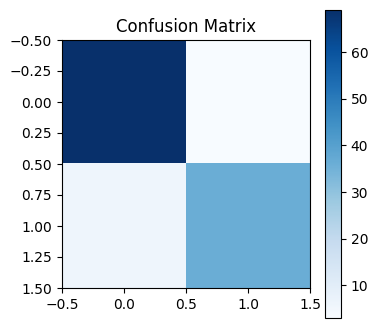

In [27]:
# Visualisasi Confusion Matrix
plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

In [28]:
# Cross-validation (5-fold Stratified) ----------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')

print("CV scores:", np.round(cv_scores, 4))
print("CV mean: {:.4f}, CV std: {:.4f}".format(cv_scores.mean(), cv_scores.std()))

CV scores: [0.9561 0.9123 0.9298 0.9035 0.9469]
CV mean: 0.9297, CV std: 0.0199


In [29]:
# simpan model
save_dir = "/content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum09/models"
os.makedirs(save_dir, exist_ok=True)

save_path = f"{save_dir}/naive_bayes_pipeline.pkl"

# Simpan pipeline model
joblib.dump({
    'pipeline': pipeline,
    'target_encoder': le_target,
    'feature_columns': X.columns.tolist()
}, save_path)

print("Model saved to:", save_path)

# Simpan summary ke file txt
summary_path = f"{save_dir}/report_summary.txt"

with open(summary_path, 'w') as f:
    f.write(f"Dataset shape: {cancer_data.shape}\n")
    f.write(f"Target: {target_col}\n")
    f.write("Model: GaussianNB (with imputer+scaler)\n")
    f.write(f"Train acc: {train_acc:.4f}\n")
    f.write(f"Test acc: {test_acc:.4f}\n")
    f.write(f"CV scores: {np.round(cv_scores,4).tolist()}\n")
    f.write(f"CV mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}\n")

print("Summary saved to:", summary_path)

Model saved to: /content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum09/models/naive_bayes_pipeline.pkl
Summary saved to: /content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum09/models/report_summary.txt
